# Non-interacting bandstructure

taking the 2 orbital model with the |x,up>, |y,down> state and adding a third dimension

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
from numpy import pi
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm
import itertools
from matplotlib.colors import LinearSegmentedColormap
colors = ['C0','C1','C2','C3','C4','C5','C6','C7','C8','C0','C1','C2','C3','C4','C5','C6','C7','C8']

from blochK.plotting import plot_FS, plot_bandstruc
from blochK.plotting.utils import sample_square, extent
from blochK.observable import exp_value_O,conductivity_orbital_resolved, local_dos_QPI, find_Gamma

from alter_surf.hamiltonian_DLKK import create_H_DLKK_3D, create_H_DLKK_true3D, create_H_DLKK_true3Das2D
from alter_surf.utils3D import projector2layer,project_doublelayer

from tqdm import tqdm
import pickle


#import blochK.utils.

In [2]:
Hparam0 = dict(len_z=19,t=1,delta=1, tp=0.3, tz=1, PBC=False, mAF=3,mu=3.1) #strong d-wave pattern. pockets roughly spherical
#Hparam0 = dict(len_z=20,t=1,delta=0, tp=0.3, tz=1, PBC=False, mAF=3,mu=-0.8,jpx=1) #strong p-wave pattern. pockets roughly spherical
H_DLKK = create_H_DLKK_3D(param=Hparam0.copy()) #set up Hamiltonian with fixed len_z because it defines n_orbitals

#3D Hamiltonian
Hparam3D = Hparam0.copy()
Hparam3D.pop('len_z'); Hparam3D.pop('PBC');
H3D = create_H_DLKK_true3D(param=Hparam3D)
H3D_as2D = create_H_DLKK_true3Das2D(param=Hparam3D)



In the 2D DLKK model AM is possible for finite magnetization and $\delta>0$, i.e. the checkerboard pattern which defines an A sublattice (strong hopping in [1,1] direction) and a B sublattice (strong hopping in [1,-1] direction). 
When stacking the model in $z$ direction we have 2 possibilites.
1) AA stacking: stacking plaquettes with strong hoppings on top of each other, i.e. delta_Q_z=0
2) AB stacking: stacking plaquettes with strong hoppings on top of plaquttes with weak hoppings, i.e. delta_Q_z $=\pi$

The magnetization in $z$-direction can now also be alternating Q_z $=\pi$ or even Q_z $=0$. That gives us 4 cases:
1)  delta_Q_z $=0$, Q_z $=0$: AM (same symmetries as 2D DLKK model)
2)  delta_Q_z $=0$, Q_z $=\pi$: AFM (spin flip + $z$-translation is a symmetry)
3)  delta_Q_z $=\pi$, Q_z $=0$: AFM (spin flip + $z$-translation + $x$-translation is a symmetry)
4)  delta_Q_z $=\pi$, Q_z $=\pi$: AM (all up sites have strong hopping in [11] direction)

The state 2. is a good starting point. It can be stabilized in a 3D Hubbard model.

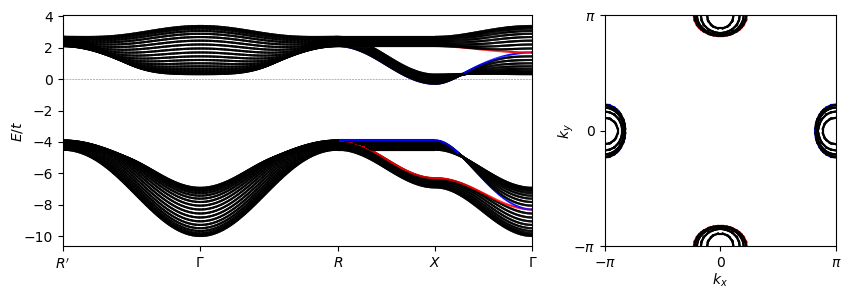

In [3]:
mu = 0.
fig, [ax,ax1] = plt.subplots(1,2,gridspec_kw={'width_ratios': [2,1]},figsize=(10,3))

#some special points of the brillouin zone

labels = ["R'",r'\Gamma','R',"X",r'\Gamma']

coloring_operator = H_DLKK.operator.spin

cmap = 'bwr'

ax.axhline(mu,linestyle='--',color='gray',linewidth=0.4)
plot_bandstruc(ax,H_DLKK,labels_points_path=labels,coloring_operator=coloring_operator,cmap=cmap)
H_DLKK.update_params(dict(mu=Hparam0['mu']+mu))
plot_FS(ax1,H_DLKK,coloring_operator=coloring_operator,cmap=cmap,Lk=50)
H_DLKK.update_params(dict(mu=Hparam0['mu']))


## Comparing different implementations

Make sure you choose an EVEN numbers of layers for that. Otherwise boundary conditions cannot be satisfied.

I everything is correct, the first and second figure should be identical.

{'t': 1, 'delta': 1, 'tp': 0.3, 'tz': 1, 'mAF': 3, 'mu': 3.1}
{'len_z': 19, 't': 1, 'delta': 1, 'tp': 0.3, 'tz': 1, 'PBC': False, 'mAF': 3, 'mu': 3.1, 'numb_z': 10}


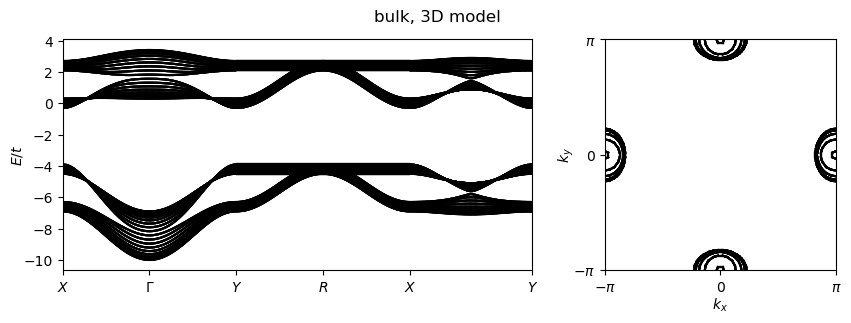

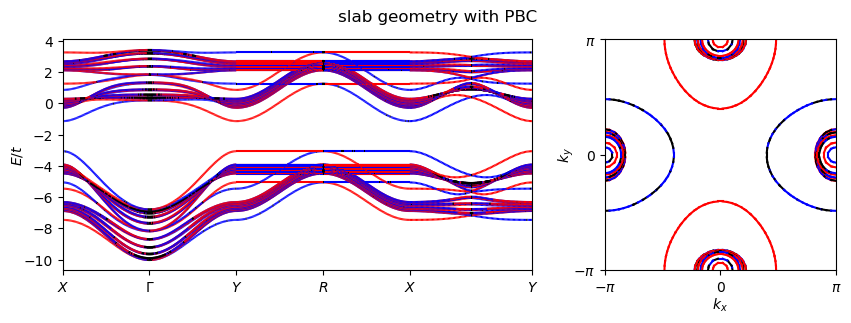

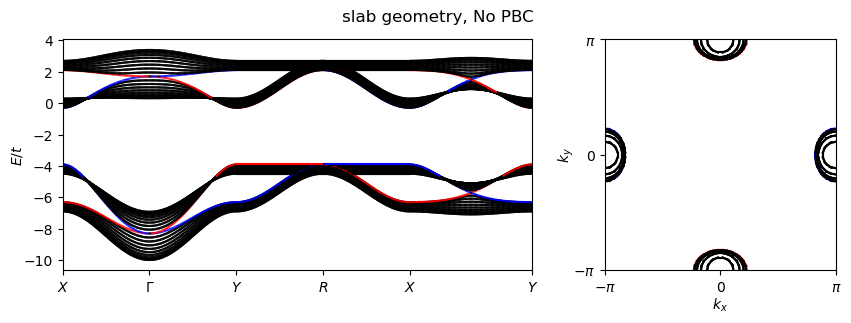

In [4]:
print(H3D_as2D.param)
print(H_DLKK.param)

labels = ['X',r'\Gamma',"Y","R","X",'Y']
coloring_operator = None
cmap = 'bwr'

#2D model
fig, [ax,ax1] = plt.subplots(1,2,gridspec_kw={'width_ratios': [2,1]},figsize=(10,3))
fig.suptitle('bulk, 3D model')
for kz in np.linspace(-2*np.pi,2*np.pi,H_DLKK.param['len_z'],endpoint=False):
    H3D_as2D.update_params(dict(kz=kz))
    plot_bandstruc(ax,H3D_as2D,labels_points_path=labels,cmap=cmap,coloring_operator=H3D_as2D.operator.spin)
    plot_FS(ax1,H3D_as2D,cmap=cmap,coloring_operator=H3D_as2D.operator.spin,Lk=50,)
#ax.set_ylim(-0.4,0.4)

#with PBC
H_DLKK.update_params(dict(PBC=True))
fig, [ax,ax1] = plt.subplots(1,2,gridspec_kw={'width_ratios': [2,1]},figsize=(10,3))
fig.suptitle('slab geometry with PBC')
plot_bandstruc(ax,H_DLKK,labels_points_path=labels,cmap=cmap,coloring_operator=H_DLKK.operator.spin)
plot_FS(ax1,H_DLKK,cmap=cmap,coloring_operator=H_DLKK.operator.spin,Lk=50,)
#ax.set_ylim(-0.4,0.4)

#without PBC
H_DLKK.update_params(dict(PBC=False))
fig, [ax,ax1] = plt.subplots(1,2,gridspec_kw={'width_ratios': [2,1]},figsize=(10,3))
fig.suptitle('slab geometry, No PBC')
plot_bandstruc(ax,H_DLKK,labels_points_path=labels,cmap=cmap,coloring_operator=H_DLKK.operator.spin)
plot_FS(ax1,H_DLKK,cmap=cmap,coloring_operator=H_DLKK.operator.spin,Lk=50,)
#ax.set_ylim(-0.4,0.4)


## Plotting the spectral function

In [5]:
Lq = 101 #MF_parameters['Lq'] #number of k-points in each direction

# Define the k-point grid
ks = sample_square(Lq)
#Diagonalize Hamiltonian
es,psis = H_DLKK.diagonalize(*ks)

def plot_spectral_density(ax,spectral_density,cmap='bwr',title_plot='',show_xlabel=True,show_ylabel=True,vmax='',vmin='',linthresh=1e-2,alphas=None):
    """Plots colored spin spectral density on ax,

    cmap: a matplotlib colormap
    title_plot: title of the plot if given
    vmax: maximum value for color scaling
    """
    if title_plot!='':
         ax.set_title(title_plot,fontsize=6)
    ax.set_aspect('equal')
    if show_xlabel:
        ax.set_xlabel(r'$k_x$',labelpad=1)
        ax.set_xticks([-pi,0,pi])
        ax.set_xticklabels([r'$-\pi$',0,r'$\pi$'])
    else:
        ax.set_xticklabels([])
    if show_ylabel:
        ax.set_ylabel(r'$k_y$',labelpad=-2.5)
        ax.set_yticks([-pi,0,pi])
        ax.set_yticklabels([r'$-\pi$',0,r'$\pi$'])
    else:
        ax.set_yticklabels([])
    ax.set_xlim(-pi,pi)
    ax.set_ylim(-pi,pi)
    #--------------
    if vmax == '':
        vmax = 1
    if vmin == '':
        vmin = -1
    
    if alphas is None:
        im = ax.imshow(spectral_density.T,extent=(-pi,pi,-pi,pi),origin='lower',cmap=cmap,norm=matplotlib.colors.SymLogNorm(linthresh=linthresh,vmin=vmin,vmax=vmax))
    else:
        im = ax.imshow(spectral_density.T,extent=(-pi,pi,-pi,pi),origin='lower',cmap=cmap,norm=matplotlib.colors.SymLogNorm(linthresh=linthresh,vmin=vmin,vmax=vmax),alpha=alphas.T)
    return im


#create a custom colormap bkr
# grab the endpoints from bwr
cmap_bwr = matplotlib.colormaps["bwr"]
# define your own colormap: blue → black → red
colors = [cmap_bwr(0.0), (0, 0, 0, 1),cmap_bwr(1.0)]
cmap_bkr = LinearSegmentedColormap.from_list("bkr", colors, N=256)


ValueError: operands could not be broadcast together with shapes (80,) (76,) 

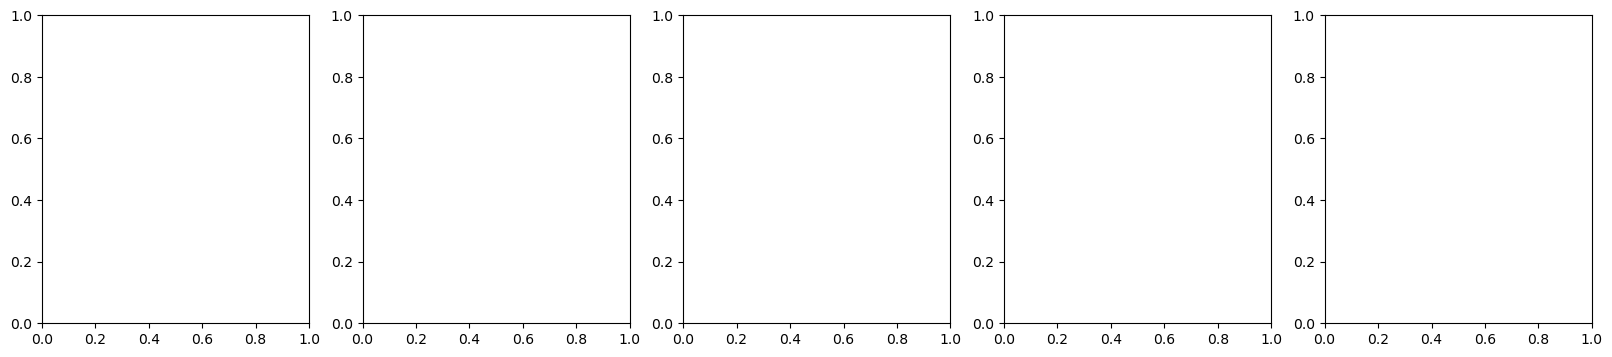

In [ ]:
Gamma = 5e-2
mu = 0
len_z = Hparam0['len_z']
#layers = [0,len_z//6,len_z//3,len_z//2]
layers = np.linspace(0,len_z-2,5,dtype=int)


fig,axs = plt.subplots(1,len(layers),figsize=(4*len(layers),4))

for ax,layer in zip(axs,layers):

    #this we need to improve if we want to measure the last layer
    coloring_operator = project_doublelayer(layer,H_DLKK)*H_DLKK.operator.spin #projected spin_operator

    #compute spin spectral density
    Os = exp_value_O(coloring_operator,psis) #.shape=(n,y,x)
    spectral_density_spin = np.sum(Os*Gamma/((es-mu)**2+Gamma**2),axis=0)/H_DLKK.param['numb_z']

    #compute spectral density
    Os = exp_value_O(H_DLKK.suboperator.proj.dot(project_doublelayer(layer,H_DLKK)),psis) #.shape=(n,y,x)
    spectral_density0 = np.sum(Os*Gamma/((es-mu)**2+Gamma**2),axis=0)/H_DLKK.param['numb_z']

    if layer == 0:
        vmax_spin = np.abs(spectral_density_spin).max()
        vmax0 = np.abs(spectral_density0).max()


    alphas = spectral_density0/vmax0
    spectral_density_spin = spectral_density_spin/vmax_spin

    #ax.imshow(spectral_density[i],cmap='gray_r')

    imT = plot_spectral_density(ax,spectral_density_spin,title_plot='Layer '+str(layer),show_ylabel=(layer==0),alphas=alphas,cmap=cmap_bkr)
    



# #Plot spin and spectral density seperately
# fig,axs = plt.subplots(2,len(layers),figsize=(4*len(layers),8))

# for ax_column,layer in zip(axs.T,layers):
#     proj_2layers = projector2layer(layer,len_z=len_z)+projector2layer(layer+1,len_z=len_z)
#     coloring_operator = np.kron(proj_2layers,H_DLKK.suboperator.spin) #projected spin_operator

#     #compute spin spectral density
#     Os = exp_value_O(coloring_operator,psis) #.shape=(n,y,x)
#     spectral_density_spin = np.sum(Os*Gamma/((es-mu)**2+Gamma**2),axis=0)/len_z

#     #compute spectral density
#     Os = exp_value_O(np.kron(proj_2layers,np.ones(4)),psis) #.shape=(n,y,x)
#     spectral_density0 = np.sum(Os*Gamma/((es-mu)**2+Gamma**2),axis=0)/len_z

    
#     vmax_spin = np.abs(spectral_density_spin).max()
#     vmax0 = np.abs(spectral_density0).max()

#     imT = plot_spectral_density(ax_column[0],spectral_density_spin,title_plot='Layer '+str(layer),show_ylabel=(layer==0),show_xlabel=False,vmax=vmax_spin)
#     imB = plot_spectral_density(ax_column[1],spectral_density0,show_ylabel=(layer==0),show_xlabel=True,vmax=vmax0,vmin=0,cmap='Greys')
    
#     #colorbars for each plot
#     plt.colorbar(imT,ax=ax_column[0],fraction=0.046,pad=0.04)
#     plt.colorbar(imB,ax=ax_column[1],fraction=0.046,pad=0.04)    


# # plt.colorbar(imT,ax=axs[0,-1],fraction=0.046,pad=0.04)
# # plt.colorbar(imB,ax=axs[1,-1],fraction=0.046,pad=0.04)

plt.tight_layout()


In [51]:
## creating the spectral density data
layers = np.arange(0,len_z-1,2,dtype=int)

spectral_densitys = []
spin_spectral_densitys = []
for layer in tqdm(layers):
    proj_2layers = projector2layer(layer,len_z=len_z)+projector2layer(layer+1,len_z=len_z)
    proj_spin = np.kron(proj_2layers,H_DLKK.suboperator.spin) #projected spin_operator

    #compute spin spectral density
    Os = exp_value_O(proj_spin,psis) #.shape=(n,y,x)
    spin_spectral_density = np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/len_z
    spin_spectral_densitys.append(spin_spectral_density)
    #compute spectral density
    Os = exp_value_O(np.kron(proj_2layers,np.ones(4)),psis) #.shape=(n,y,x)
    spectral_density0 = np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/len_z
    spectral_densitys.append(spectral_density0)

spectral_density = np.array(spectral_densitys)
spin_spectral_density = np.array(spin_spectral_densitys)


with open('analysis/spectral_densitys_DLKK.pkl','wb') as f:
    pickle.dump({'spectral_density':spectral_density,
                 'spin_spectral_density':spin_spectral_density,
                 'layers':layers,
                 'k_mesh':ks}, f)
f.close()

100%|██████████| 5/5 [00:00<00:00,  7.49it/s]


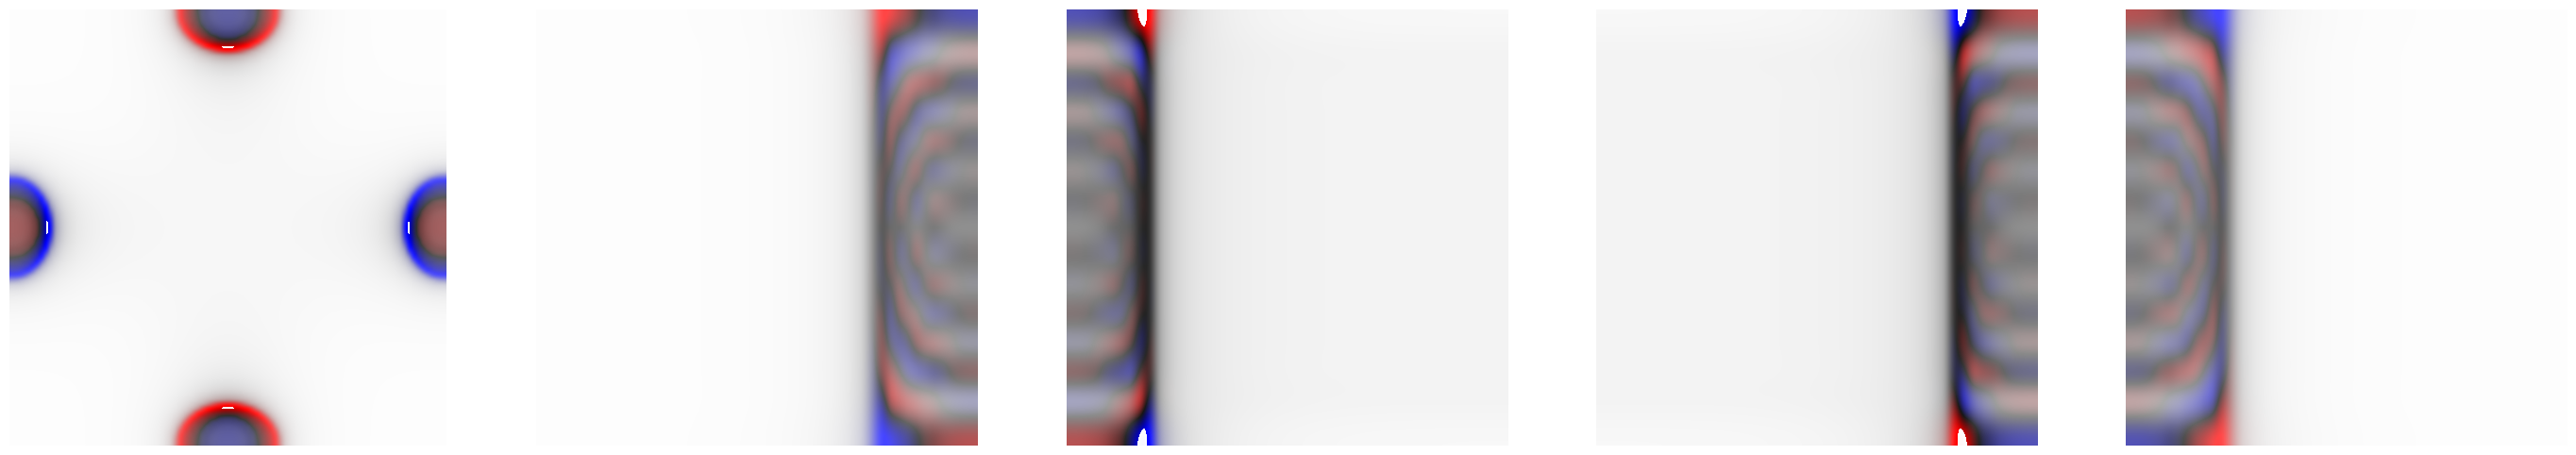

In [81]:
colors = spin_spectral_density.copy()
alphas = spectral_density.copy()
export = True

#nomalize for plotting
colors = spin_spectral_density/np.max(np.abs(spin_spectral_density))
alphas = spectral_density/np.max(np.abs(spectral_density))

#power law for better visibility
colors = np.sign(colors)*np.abs(colors)**0.7
alphas = alphas**0.8

imshow_kwargs = dict(origin='lower',vmax=1, vmin=-1,interpolation='spline36')

fig,axs = plt.subplots(1,5,figsize=(35,6))
numb_ks = ks.shape[1]

#########################################
#surface
#########################################
axs[0].set_title('Spectral Density layer 0')
axs[0].set_xlabel('$k_x$')
axs[0].set_ylabel('$k_y$')
i=0
colors0 = colors[i].T
alphas0 = alphas[i].T
axs[0].imshow(colors0,cmap=cmap_bkr,alpha=alphas0,**imshow_kwargs,extent=extent(numb_ks))
#the lines where we cut


#########################################
#cut along kx
#########################################
axs[1].set_xlabel('$k_x$')
axs[1].set_ylabel('Layer index')
idx_ky0 = 0
axs[1].set_title(f'Spectral Density at k_y={ks[0,0,idx_ky0]:.2f}')
#cut
colors0 = colors[:,:,idx_ky0]
alphas0 = alphas[:,:,idx_ky0]
axs[1].imshow(colors0,cmap=cmap_bkr,alpha=alphas0,extent=[-np.pi,np.pi,layers[0],layers[-1]],aspect='auto',**imshow_kwargs)
axs[1].set_xlim(-np.pi,0)
axs[1].set_ylim(layers[-1],0)


#########################################
#cut along ky
#########################################
axs[2].set_xlabel('$k_y$')
axs[2].set_ylabel('Layer index')
idx_kx0 = numb_ks//2
axs[2].set_title(f'Spectral Density at k_x={ks[0,idx_kx0,0]:.2f}')
#cut
colors0 = colors[:,idx_kx0,:]
alphas0 = alphas[:,idx_kx0,:]
axs[2].imshow(colors0,cmap=cmap_bkr,alpha=alphas0,extent=[-np.pi,np.pi,layers[0],layers[-1]],aspect='auto',**imshow_kwargs)
axs[2].set_xlim(-np.pi,0)
axs[2].set_ylim(layers[-1],0)

#########################################
#cut along kx
#########################################
axs[3].set_xlabel('$k_x$')
axs[3].set_ylabel('Layer index')
idx_ky1 = numb_ks//2
axs[3].set_title(f'Spectral Density at k_y={ks[1,0,idx_ky1]:.2f}')
#cut
colors0 = colors[:,:,idx_ky1]
alphas0 = alphas[:,:,idx_ky1]
axs[3].imshow(colors0,cmap=cmap_bkr,alpha=alphas0,extent=[-np.pi,np.pi,layers[0],layers[-1]],aspect='auto',**imshow_kwargs)
axs[3].set_xlim(0,np.pi)
axs[3].set_ylim(layers[-1],0)


#########################################
#cut along ky
#########################################
axs[4].set_xlabel('$k_y$')
axs[4].set_ylabel('Layer index')
idx_kx1 = -1
axs[4].set_title(f'Spectral Density at k_y={ks[0,idx_kx1,0]:.2f}')
#cut
colors0 = colors[:,idx_kx1,:]
alphas0 = alphas[:,idx_kx1,:]
axs[4].imshow(colors0,cmap=cmap_bkr,alpha=alphas0,extent=[-np.pi,np.pi,layers[0],layers[-1]],aspect='auto',**imshow_kwargs)
axs[4].set_xlim(0,np.pi)
axs[4].set_ylim(layers[-1],0)


if export:
    for ax in axs:
        ax.set_title('')
        ax.set_axis_off()

    fig.savefig('spectral_density_cut.pdf',bbox_inches='tight')
else:
    ps = []
    ps.append(ks[:,0,idx_ky0])
    ps.append(ks[:,idx_kx0,idx_ky0])
    ps.append(ks[:,idx_kx0,idx_ky1])
    ps.append(ks[:,idx_kx1,idx_ky1])
    ps.append(ks[:,idx_kx1,-1])
    axs[0].plot(*np.transpose(ps), color='k', linestyle='--')


## Spin conductivity

In [11]:
from alter_surf.utils_DLKK import get_conductivity_layer_resolved

#setting parameters
Lk = 40 #number of k-points in each direction

layers, cond, spin_cond = get_conductivity_layer_resolved(H_DLKK,Lk=Lk)

cond_xx = cond[:,0,0]
spin_cond_xx = spin_cond[:,0,0]


NameError: name 'len_z' is not defined

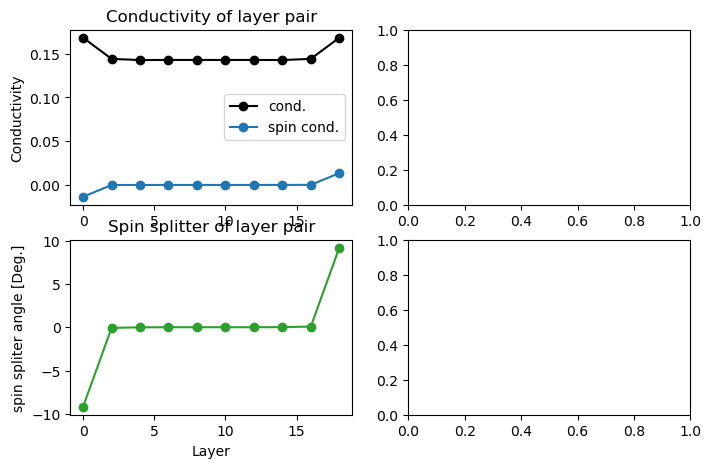

In [12]:
fig,axs = plt.subplots(2,2,figsize=(8,5))

#layer resolved
axs[0,0].set_title('Conductivity of layer pair')
axs[0,0].plot(layers,cond_xx,'ko-',label='cond.')
axs[0,0].plot(layers,spin_cond_xx,'o-',label='spin cond.')
axs[0,0].set_ylabel('Conductivity')
axs[0,0].legend()

axs[1,0].set_title('Spin splitter of layer pair')
axs[1,0].plot(layers,2*np.arctan(spin_cond_xx/cond_xx)*180/pi,'o-',color='C2')
axs[1,0].set_xlabel('Layer')
axs[1,0].set_ylabel('spin spliter angle [Deg.]')

#layer summed
lz2 = len_z//2
xs = np.arange(0,lz2)
axs[0,1].set_title('conductivity of d/2 layer pairs')
axs[0,1].plot(xs,np.cumsum(cond_xx[:lz2]),'ko-',label='cond.')
axs[0,1].plot(xs,np.cumsum(spin_cond_xx[:lz2]),'o-',label='spin cond.')
axs[0,1].legend()

axs[1,1].set_title('Spin splitter of d/2 layer pairs')
axs[1,1].plot(xs,2*np.arctan(np.cumsum(spin_cond_xx[:lz2])/np.cumsum(cond_xx[:lz2]))*180/pi,'o-',color='C2')
axs[1,1].set_xlabel('depth d')


plt.tight_layout()


## Checking the spectral density along a 1D path

Let's look at the spectral properties along the path $(0,0)$ to $(\pi,\pi)$. Then we can see efficiently how spin degneracy is restored

In [34]:
Lk = 200 #number of k-points in each direction

# Define the k-point grid
kxs = np.linspace(0,pi,Lk)
kys = kxs
#Diagonalize Hamiltonian
es,psis = H_DLKK.diagonalize(kxs,kys)

Gamma = 1e-2

#compute spectral density
layers = np.arange(0,Hparam0['len_z']//2,1,dtype=int)
spin_spec_dens = []
spec_dens = []
for layer in layers:
    proj_2layers = projector2layer(layer,len_z=param['len_z'])+projector2layer(layer+1,len_z=param['len_z'])
    coloring_operator = np.kron(proj_2layers,H_DLKK.suboperator.spin) #projected spin_operator

    #compute spin spectral density
    Os = exp_value_O(coloring_operator,psis) #.shape=(n,y,x)
    spin_spec_dens.append(np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/param['len_z'])

    #computespectral density
    Os = exp_value_O(np.kron(proj_2layers,np.ones(4)),psis) #.shape=(n,y,x)
    spec_dens.append(np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/param['len_z'])

spin_spec_dens = np.array(spin_spec_dens)
spec_dens = np.array(spec_dens)


ValueError: operands could not be broadcast together with shapes (80,200,80) (16,) 

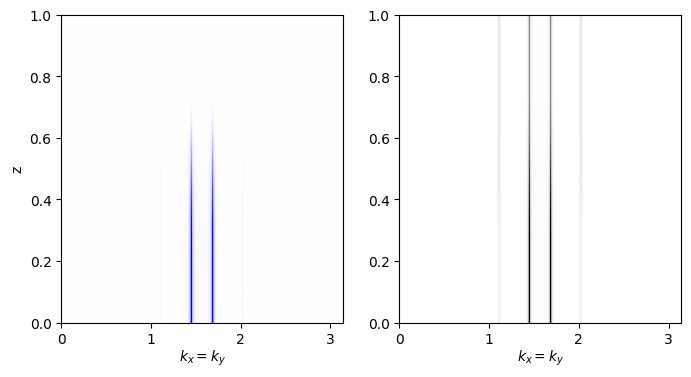

In [ ]:
fig,[ax1,ax2] = plt.subplots(1,2,figsize=(8,4))

ax1.set_xlabel('$k_x=k_y$',labelpad=1)
ax2.set_xlabel('$k_x=k_y$',labelpad=1)
ax1.set_ylabel('z')

vmax = np.abs(spin_spec_dens).max()
im1 = ax1.imshow(spin_spec_dens,extent=(0,pi,0,layers[-1]),origin='lower',cmap='bwr',vmin=-vmax,vmax=vmax,aspect='auto')
im2 = ax2.imshow(spec_dens,extent=(0,pi,0,layers[-1]),origin='lower',cmap='Greys',vmin=0,vmax=spec_dens.max(),aspect='auto')


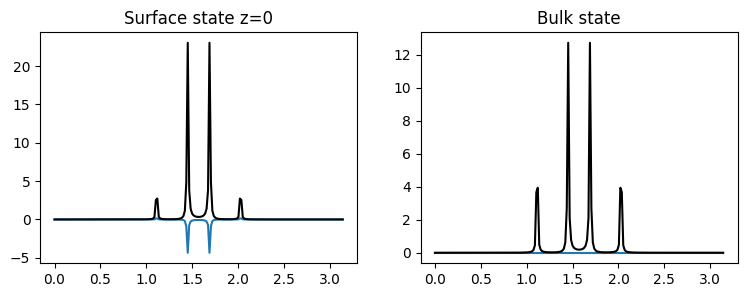

In [ ]:
fig,axs = plt.subplots(1,2,figsize=(9,3))

axs[0].set_title('Surface state z=0')
axs[0].plot(kxs,spin_spec_dens[0],'-')
axs[0].plot(kxs,spec_dens[0],'k-')

axs[1].set_title('Bulk state')
axs[1].plot(kxs,spin_spec_dens[-1],'-')
axs[1].plot(kxs,spec_dens[-1],'k-')

Text(0, 0.5, 'integrated spin density')

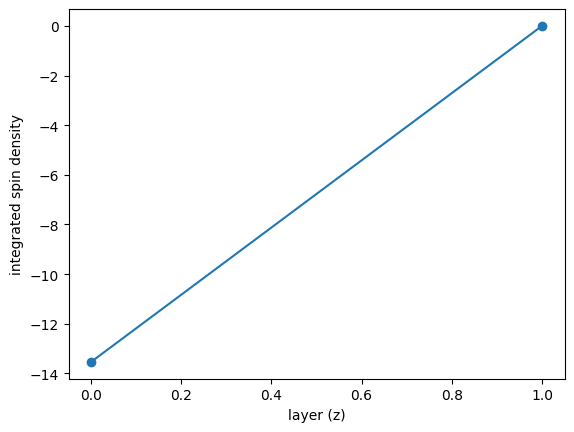

In [ ]:
plt.plot(layers,spin_spec_dens.sum(axis=-1),'o-')
plt.xlabel('layer (z)')
plt.ylabel('integrated spin density')

In [1]:
#####testing

In [17]:
#setting parameters
Lk = 20 #number of k-points in each direction

len_z = Hparam0['len_z']

# Calculate spin conductivity
cond_tensor = conductivity_orbital_resolved(H_DLKK,Lk=Lk,optimize='path') #.shape=(localH,x,y)

sc = []
c = []
for layer in layers:
    proj = project_doublelayer(layer,H_DLKK)
    Spin_op_layer = proj*H_DLKK.operator.spin #projected spin_operator
    sc.append(np.sum(Spin_op_layer*cond_tensor[:,0,0]))
    c.append(np.sum(proj*cond_tensor[:,0,0]))

sc = np.array(sc)
c = np.array(c)

In [25]:
#setting parameters
from blochK.observable import conductivity
Lk = 20 #number of k-points in each direction

len_z = Hparam0['len_z']

# Calculate spin conductivity

sc2 = []
c2 = []
for layer in layers:

    proj = project_doublelayer(layer,H_DLKK)

    x = conductivity(H_DLKK,Lk=Lk,operator=np.diag(proj*H_DLKK.operator.spin)) #.shape=(localH,x,y)
    sc2.append(x[0,0])
    
    x = conductivity(H_DLKK,Lk=Lk,operator=np.diag(proj)) #.shape=(localH,x,y)
    c2.append(x[0,0])

sc2 = np.array(sc2)
c2 = np.array(c2)

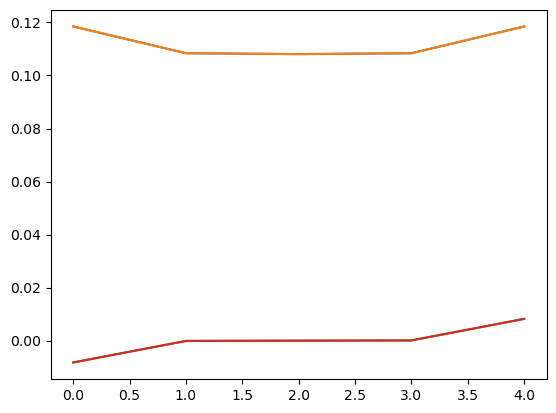

In [42]:
plt.plot(c)
plt.plot(c2)
plt.plot(sc)
plt.plot(sc2)

In [43]:
len_z

10

In [40]:
a = np.random.rand(10)
b = np.random.rand(10)

M = np.random.rand(10,10)

proj = np.zeros(10)
proj[0:2] = 1
proj = np.diag(proj)

print(a.dot(proj).dot(M).dot(b)/2 + a.dot(M).dot(proj).dot(b)/2)

print(a.dot(proj).dot(M).dot(proj).dot(b))

3.22951154828898
0.5681688120715013
